Q1. Data Loading & Understanding

a) Load the dataset into Python.

b) Display the first 5 rows.

c) Check the shape of the dataset.

d) Display the data types of each column.



```

# Import required libraries
import pandas as pd

# a) Load the dataset into Python
df = pd.read_excel('Downloads/loan_approval.xlsx')

df.head()

df.shape

df.dtypes

```

Solution:

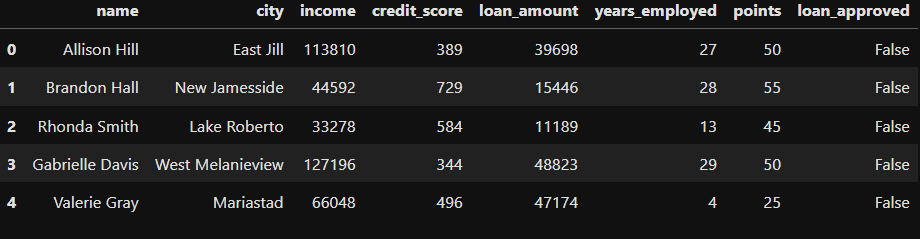

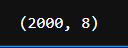

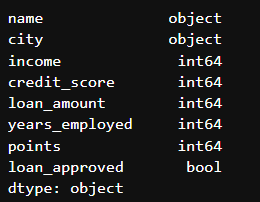

Q2. Data Cleaning

a) Check for missing values in the dataset.
b) Handle missing values appropriately.
c) Identify categorical columns present in the dataset.



```

# a) Check for missing values in the dataset
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())


# b) Handle missing values appropriately

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill numerical missing values with mean
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical missing values with mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


# c) Identify categorical columns present in the dataset
print("\nCategorical Columns in Dataset:")
print(list(categorical_cols))
```
Solution:

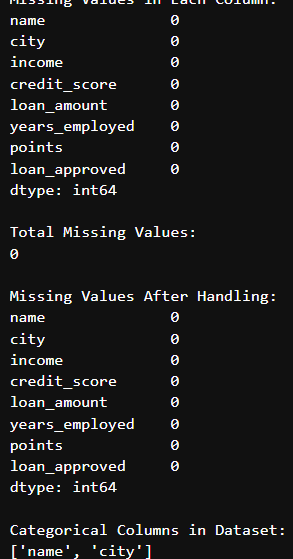

Q3. Exploratory Data Analysis (EDA)

a) Plot the distribution of the target variable.
b) Analyze the relationship between one numerical feature and the target variable.
c) Analyze the relationship between Years of Employment and the target variable.



```
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of target variable

plt.figure(figsize=(6,4))
sns.countplot(x='loan_approved', data=df)

plt.title("Distribution of Loan Approval Status")
plt.xlabel("Loan Status (0 = Not Approved, 1 = Approved)")
plt.ylabel("Count")

plt.show()

# Relationship between ApplicantIncome and Loan_Status

plt.figure(figsize=(8,5))

sns.boxplot(x='loan_approved', y='income', data=df)

plt.title("Applicant Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")

plt.show()

# Relationship between Years of Employment and Loan_Status

plt.figure(figsize=(8,5))

sns.boxplot(x='loan_approved', y='years_employed', data=df)

plt.title("Years of Employment vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Years of Employment")

plt.show()
```
Solution:
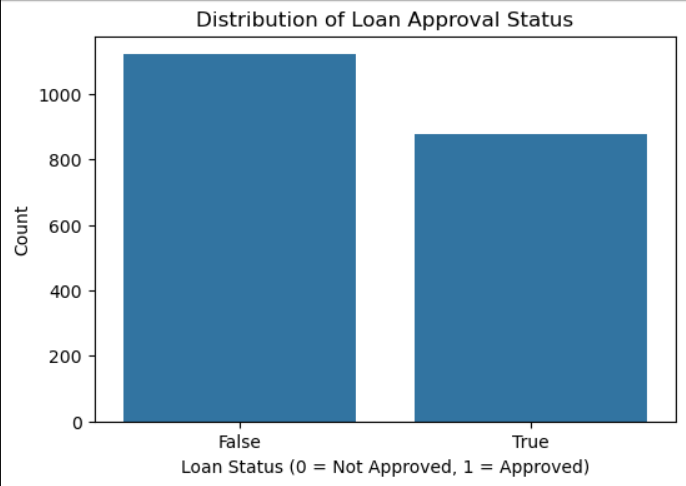

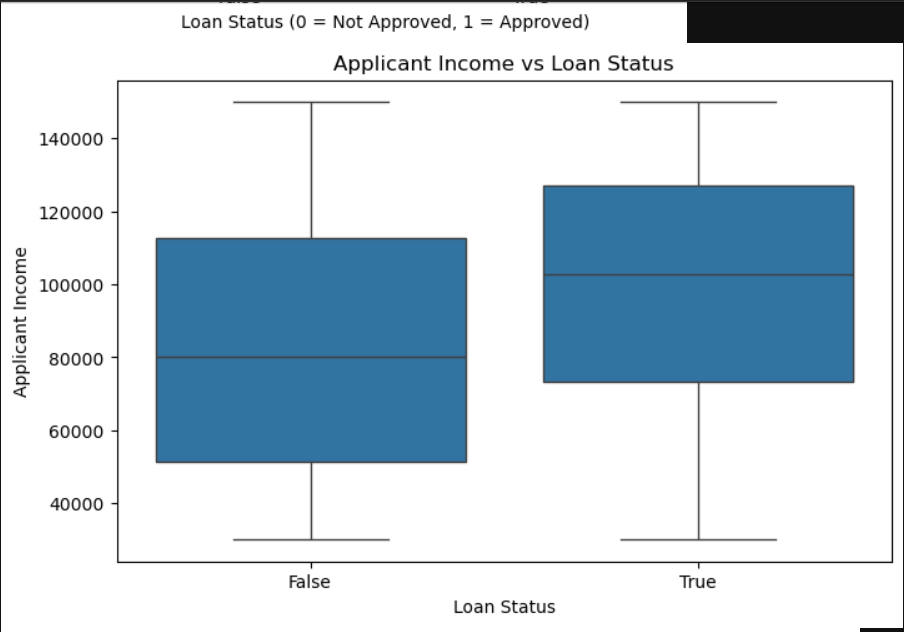

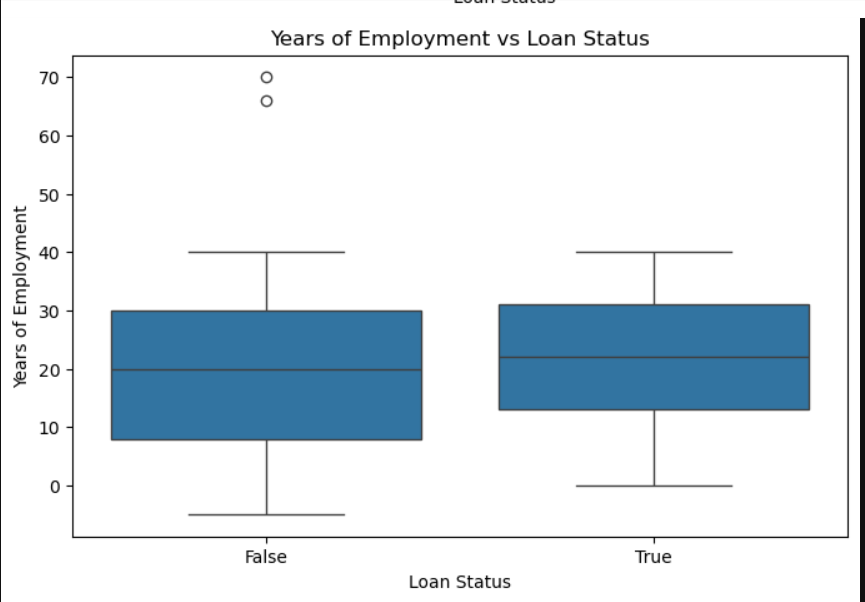

Q4. Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method.
b) Treat outliers using capping techniques



```
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Detect outliers using IQR method

for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\nColumn: {col}")
    print(f"Number of Outliers: {outliers.shape[0]}")


# Treat outliers using capping

for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Apply capping
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outlier treatment completed successfully.", df[col] )
```

Solution:

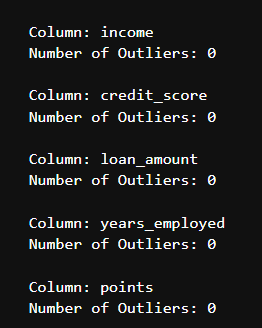

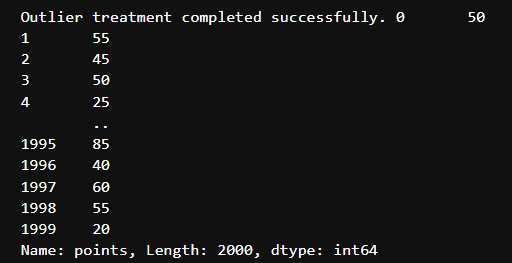

Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
columns.



```
# Example: Convert target variable into numerical format

df['loan_approved'] = df['loan_approved'].map({
    'Y': 1,
    'N': 0
})

# Display first 5 rows
print(df[['loan_approved']].head())

# Convert categorical columns into numerical format

df = pd.get_dummies(df, drop_first=True)

print(df.head())


```
Solution:

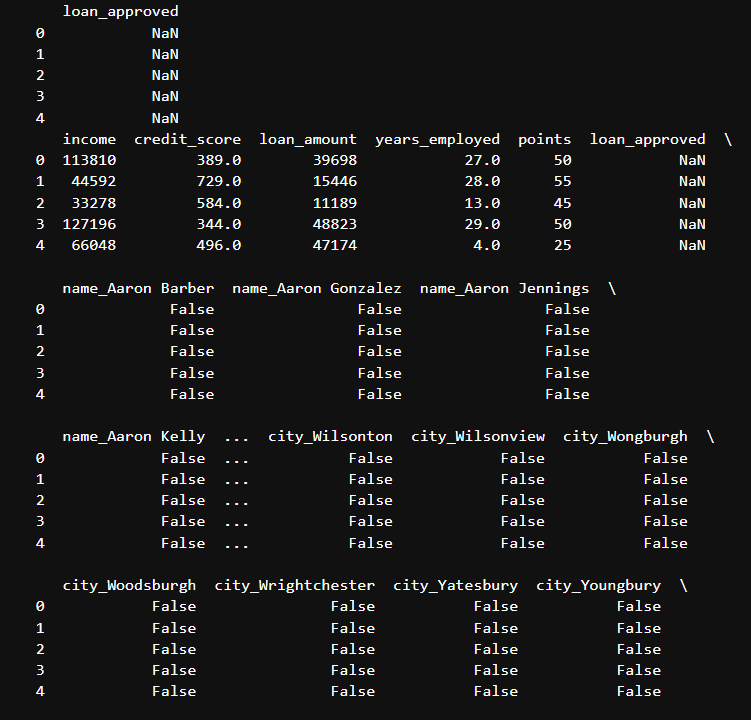

Q6. Feature Selection and Data Splitting

a) Separate independent variables (X) and dependent variable (y).                                             

b) Split the dataset into training and testing sets.


```
# Separate features and target variable

X = df.drop('loan_approved', axis=1)   # Independent variables
y = df['loan_approved']                # Dependent variable

# Display shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


```

Solution:

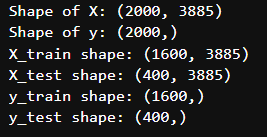

Q7. Apply feature scaling to the dataset using StandardScaler.

```
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Apply scaling on training and testing data

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display scaled data shape

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
```

Solution:

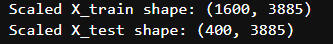  

Q8. Logistic Regression Model Building

a) Train a Logistic Regression model.
b) Predict the output for test data.



```
# Import libraries

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------
# Check all column names
# ------------------------------------------------

print(df.columns)

# ------------------------------------------------
# Put your ACTUAL target column name here
# Example:
# target_column = 'LoanApproved'
# ------------------------------------------------

target_column = 'Loan_Status'   # CHANGE THIS

# ------------------------------------------------
# Remove missing values
# ------------------------------------------------

df = df.dropna(subset=[target_column])

# ------------------------------------------------
# Separate X and y
# ------------------------------------------------

X = df.drop(target_column, axis=1)
y = df[target_column]

# ------------------------------------------------
# Convert y into numeric if needed
# ------------------------------------------------

if y.dtype == 'object':
    y = y.map({'Y':1, 'N':0, 'Yes':1, 'No':0})

# ------------------------------------------------
# Remove remaining missing values
# ------------------------------------------------

X = X.fillna(X.mean(numeric_only=True))

# ------------------------------------------------
# Convert categorical columns into numeric
# ------------------------------------------------

X = pd.get_dummies(X, drop_first=True)

# ------------------------------------------------
# Split dataset
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------
# Feature Scaling
# ------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------
# Train Logistic Regression Model
# ------------------------------------------------

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

print("Model Trained Successfully")

# ------------------------------------------------
# Prediction
# ------------------------------------------------

y_pred = lr_model.predict(X_test_scaled)

print("\nPredictions:")
print(y_pred)
```
Q9. Model Evaluation – Confusion Matrix

a) Generate the confusion matrix.
b) Interpret the results.

```
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix

print("Confusion Matrix:")
print(cm)


The confusion matrix evaluates the classification performance of the Logistic Regression model.

Components of Confusion Matrix
True Positive (TP)
Loan approved correctly predicted as approved.

True Negative (TN)
Loan rejected correctly predicted as rejected.

False Positive (FP)
Loan rejected but predicted as approved.

False Negative (FN)
Loan approved but predicted as rejected.
```


